Implicit Scheme Heat Equation Finite Difference Method on a 1D Rod, the material is completely homogeneous

$u_t = D u_{xx}$

Implicit Scheme uses backward difference

In [1]:
import numpy as np
import matplotlib.pyplot as plt

Parameters

time = 1, time_step = 0.25, step_size = 0.25

Length = 1

Dirchelet Boundary Conditions: $U(0, t) = 1$

Diffusivity Constant: D = 5

Initial Conditions: $U(x, 0) = 0$

In [2]:
Length = 1
time_step = 0.25
step_size = 0.25
D = 0.1

In [3]:
r = (D * time_step) / (step_size**2)
r

0.4

In [4]:
# Numerical Stability
b = (step_size**2)/(2 * D)
b

0.3125

In [5]:
time_step <= b

True

In [6]:
x_range = np.arange(0, 1 + step_size, step_size)
x_range

array([0.  , 0.25, 0.5 , 0.75, 1.  ])

In [7]:
t_range = np.arange(0, 1 + time_step, time_step)

In [8]:
x_len, t_len = len(x_range), len(t_range)

In [9]:
grid = np.zeros((x_len, t_len))
grid

array([[0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.]])

Apply Dirichelet Boundary Conditions

In [10]:
grid[:,0] = np.sin(np.pi * x_range)
grid[0, :] = 0
grid[-1, :] = 0
grid

array([[0.        , 0.        , 0.        , 0.        , 0.        ],
       [0.70710678, 0.        , 0.        , 0.        , 0.        ],
       [1.        , 0.        , 0.        , 0.        , 0.        ],
       [0.70710678, 0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ]])

for i in range(1, x_len - 1):
    print(i)

In [11]:
for j in range(0, t_len - 1):
    for i in range(1, x_len - 1):
        grid[i, j + 1] = r * (grid[i + 1, j] + grid[i - 1, j]) + (1 - 2 * r) * grid[i, j]
        print(i, j)
grid

1 0
2 0
3 0
1 1
2 1
3 1
1 2
2 2
3 2
1 3
2 3
3 3


array([[0.        , 0.        , 0.        , 0.        , 0.        ],
       [0.70710678, 0.54142136, 0.41455844, 0.31742136, 0.24304491],
       [1.        , 0.76568542, 0.58627417, 0.44890159, 0.3437174 ],
       [0.70710678, 0.54142136, 0.41455844, 0.31742136, 0.24304491],
       [0.        , 0.        , 0.        , 0.        , 0.        ]])

matrix = np.zeros((x_len, t_len))

for j in range(t_len):
    for i in range(t_len):
        matrix[i, j] = np.sin(x_range[i] * np.pi) * np.exp(-np.pi**2 * D * t_range[j])

matrix.round(7)

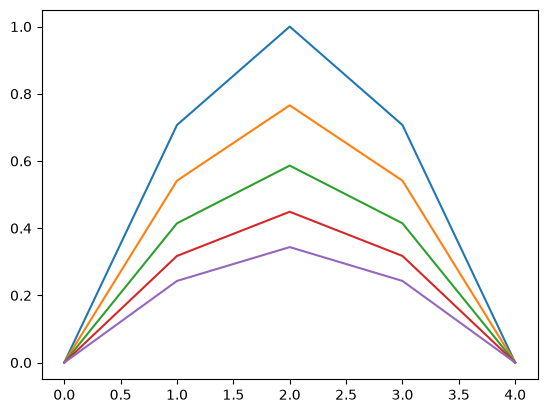

In [12]:
plt.plot(grid)